In [1]:
import pandas as pd
import numpy as np

# dfx = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/Funding flow.csv', encoding='cp1252')

dfy = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/dfy_SUBAWARD FLOW TO ENTITIES_Assistance_Subawards_2026-09-22_H20M40S39_1.csv', encoding='cp1252')
dfx = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/dfx_FUND_ORIGINS_Assistance_PrimeTransactions_2026-09-22_H20M40S34_1.csv', encoding='cp1252')
dfz = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/dfz_Assistance_PrimeAwardSummaries_2026-09-22_H20M40S30_1.csv', encoding='cp1252')
dfw = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/dfw_ACOE_12miml_TLP_Contracts_PrimeTransactions_2026-09-22_H20M40S32_1.csv', encoding='cp1252')

df = dfx.copy()

# for col in df.columns:
#     print(col)

# df

In [2]:
'''
Next steps:
- parse by year, or standardize somehow eh...
- for GA DNR: sub sankey with CIG permits (match using project description???) DONE
- Also for GA DNR - state funding for budget vs. this, which is just for restoration projects

'''

'\nNext steps:\n- parse by year, or standardize somehow\n- for GA DNR: sub sankey with CIG permits (match using project description???)\n- Also for GA DNR - state funding for budget vs. this, which is just for restoration projects\n\n'

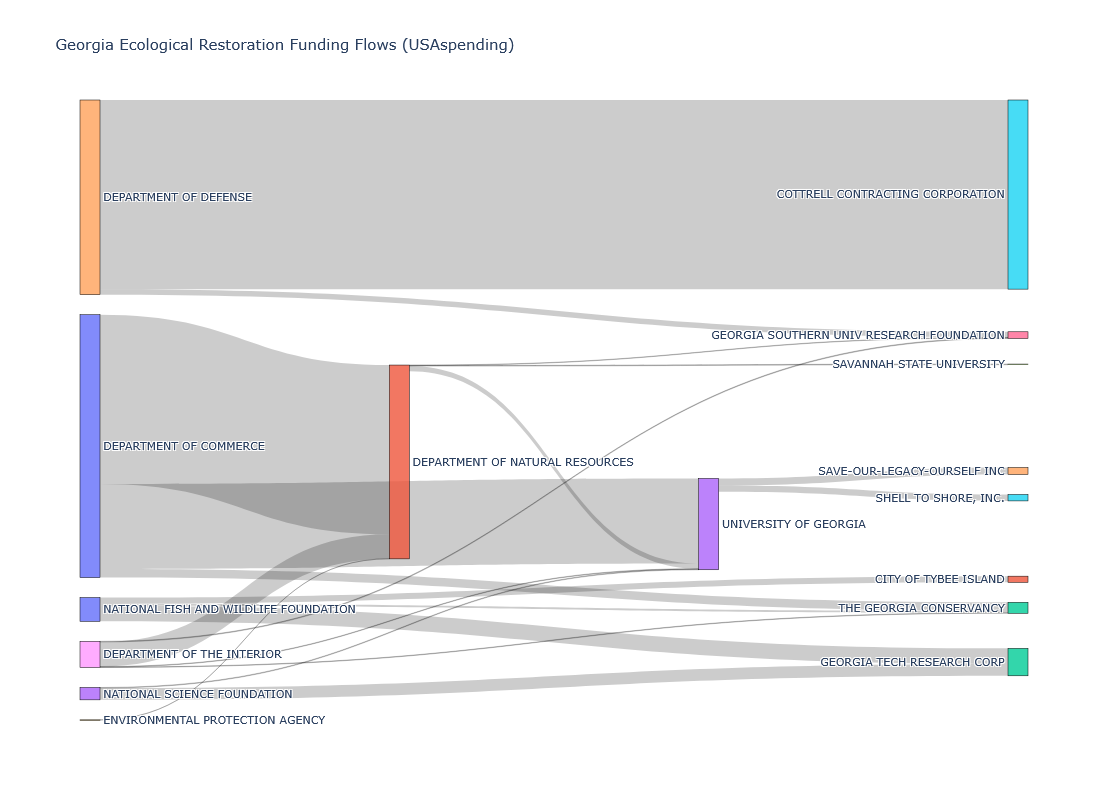

In [8]:
import pandas as pd
import plotly.graph_objects as go

# ---------------------------------------------------------
# 1. Helper Functions & Normalization Mappings
# ---------------------------------------------------------
def clean_id(x):
    if pd.isna(x):
        return None
    return str(x).strip().upper()

AGENCY_PARENT_MAP = {
    'US ARMY CORPS OF ENGINEERS': 'DEPARTMENT OF DEFENSE',
    'DEPARTMENT OF THE ARMY': 'DEPARTMENT OF DEFENSE',
    'CIVIL WORKS': 'DEPARTMENT OF DEFENSE',
    'CORPS OF ENGINEERS - CIVIL WORKS': 'DEPARTMENT OF DEFENSE',
    'NATIONAL OCEANIC AND ATMOSPHERIC ADMINISTRATION': 'DEPARTMENT OF COMMERCE',
    'UNITED STATES FISH AND WILDLIFE SERVICE': 'DEPARTMENT OF THE INTERIOR',
    'NATIONAL PARK SERVICE': 'DEPARTMENT OF THE INTERIOR',
    'US FOREST SERVICE': 'DEPARTMENT OF AGRICULTURE',
    'NATURAL RESOURCES CONSERVATION SERVICE': 'DEPARTMENT OF AGRICULTURE',
}

def standardize_agency(agency_name):
    if pd.isna(agency_name):
        return 'UNKNOWN FEDERAL AGENCY'
    name_upper = str(agency_name).strip().upper()
    return AGENCY_PARENT_MAP.get(name_upper, name_upper)

# Entity name mapping for duplicate variants (GA DNR, UGA, GSU, GA Tech, etc.)
ENTITY_CLEAN_MAP = {
    # GA DNR variants
    'NATURAL RESOURCES, GEORGIA DEPARTMENT OF': 'DEPARTMENT OF NATURAL RESOURCES',
    'GEORGIA DEPARTMENT OF NATURAL RESOURCES': 'DEPARTMENT OF NATURAL RESOURCES',
    'GA DEPT OF NATURAL RESOURCES': 'DEPARTMENT OF NATURAL RESOURCES',
    
    # Georgia Southern variants
    'GEORGIA SOUTHERN UNIVERSITY RESEARCH & SERVICE FOUNDATION INC': 'GEORGIA SOUTHERN UNIV RESEARCH FOUNDATION',
    'GEORGIA SOUTHERN UNIVERSITY RESEARCH AND SERVICE FOUNDATION, INC.': 'GEORGIA SOUTHERN UNIV RESEARCH FOUNDATION',
    'GEORGIA SOUTHERN UNIVERSITY RESEARCH AND SERVICE FOUNDATION': 'GEORGIA SOUTHERN UNIV RESEARCH FOUNDATION',
    'GEORGIA SOUTHERN UNIVERSITY RESEARCH AND SERV': 'GEORGIA SOUTHERN UNIV RESEARCH FOUNDATION',
    
    # UGA variants
    'UNIVERSITY OF GEORGIA': 'UNIVERSITY OF GEORGIA',
    'UNIVERSITY OF GEORGIA RESEARCH FOUNDATION, INC.': 'UNIVERSITY OF GEORGIA',
    
    # Georgia Tech variants
    'GEORGIA TECH RESEARCH CORP': 'GEORGIA TECH RESEARCH CORP',
    'GEORGIA TECH RESEARCH CORPORATION': 'GEORGIA TECH RESEARCH CORP',
    
    # Other non-profit variants
    'GEORGIA CONSERVANCY INC, THE': 'THE GEORGIA CONSERVANCY',
}

def clean_entity(name):
    if pd.isna(name):
        return None
    n = str(name).strip().upper()
    return ENTITY_CLEAN_MAP.get(n, n)

# Clean IDs across datasets
for df, cols in [
    (dfx, ['award_id_fain', 'assistance_award_unique_key']),
    (dfy, ['prime_award_fain', 'prime_award_unique_key']),
    (dfz, ['award_id_fain', 'assistance_award_unique_key']),
    (dfw, ['award_id_piid', 'contract_award_unique_key'])
]:
    for col in cols:
        if col in df.columns:
            df[col] = df[col].map(clean_id)

# ---------------------------------------------------------
# 2. Build Assistance Prime Edges (dfx) with Fallback Logic
# ---------------------------------------------------------
dfx_amounts = dfx.groupby('award_id_fain').agg(
    transaction_sum=('federal_action_obligation', 'sum'),
    award_total=('total_obligated_amount', 'max'),
    outlay_total=('total_outlayed_amount_for_overall_award', 'max')
).reset_index()

# Multi-tier fallback: transaction sum -> total obligated -> total outlayed
def calc_dfx_effective(r):
    if r['transaction_sum'] <= 0 and r['award_total'] > 0:
        return r['award_total']
    if r['transaction_sum'] <= 0 and r['award_total'] <= 0 and r['outlay_total'] > 0:
        return r['outlay_total']
    return r['transaction_sum']

dfx_amounts['effective_amount'] = dfx_amounts.apply(calc_dfx_effective, axis=1)

prime_assistance = dfx.groupby('award_id_fain').first().reset_index()
prime_assistance = prime_assistance.merge(dfx_amounts[['award_id_fain', 'effective_amount']], on='award_id_fain')

prime_assistance_edges = pd.DataFrame({
    'award_id_fain': prime_assistance['award_id_fain'],
    'source': prime_assistance['funding_agency_name'].fillna(prime_assistance['awarding_agency_name']).apply(standardize_agency),
    'target': prime_assistance['recipient_name'].apply(clean_entity),
    'amount': prime_assistance['effective_amount']
})

# ---------------------------------------------------------
# 3. Build Contract Prime Edges (dfw) with Fallback Logic
# ---------------------------------------------------------
dfw_amounts = dfw.groupby('award_id_piid').agg(
    transaction_sum=('federal_action_obligation', 'sum'),
    award_total=('total_dollars_obligated', 'max')
).reset_index()

dfw_amounts['effective_amount'] = dfw_amounts.apply(
    lambda r: r['award_total'] if (r['transaction_sum'] == 0 and r['award_total'] > 0) else r['transaction_sum'],
    axis=1
)

prime_contracts = dfw.groupby('award_id_piid').first().reset_index()
prime_contracts = prime_contracts.merge(dfw_amounts[['award_id_piid', 'effective_amount']], on='award_id_piid')

prime_contract_edges = pd.DataFrame({
    'award_id_fain': prime_contracts['award_id_piid'],
    'source': prime_contracts['funding_agency_name'].fillna(prime_contracts['awarding_agency_name']).apply(standardize_agency),
    'target': prime_contracts['recipient_name'].apply(clean_entity),
    'amount': prime_contracts['effective_amount']
})

# ---------------------------------------------------------
# 4. Build Subaward Edges (dfy)
# ---------------------------------------------------------
sub_edges = pd.DataFrame({
    'award_id_fain': dfy['prime_award_fain'],
    'source': dfy['prime_awardee_name'].apply(clean_entity),
    'target': dfy['subawardee_name'].apply(clean_entity),
    'amount': pd.to_numeric(dfy['subaward_amount'], errors='coerce').fillna(0)
})

# ---------------------------------------------------------
# 5. Combine All Edges & Aggregate
# ---------------------------------------------------------
all_edges = pd.concat([prime_assistance_edges, prime_contract_edges, sub_edges], ignore_index=True)

# Filter out zero or negative obligations
all_edges = all_edges[all_edges['amount'] > 0]

# Consolidate duplicate source -> target flows
sankey_edges = all_edges.groupby(['source', 'target'], as_index=False).agg(amount=('amount', 'sum'))

# ---------------------------------------------------------
# 6. Build Plotly Sankey Diagram
# ---------------------------------------------------------
nodes = list(pd.unique(sankey_edges[['source', 'target']].values.ravel()))
node_index = {name: i for i, name in enumerate(nodes)}

fig = go.Figure(go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=sankey_edges['source'].map(node_index),
        target=sankey_edges['target'].map(node_index),
        value=sankey_edges['amount'],
        hovertemplate='From: %{source.label}<br>To: %{target.label}<br>Amount: $%{value:,.2f}<extra></extra>'
    )
))

fig.update_layout(
    title_text="Georgia Ecological Restoration Funding Flows (USAspending)",
    font_size=11,
    height=800
)



##Save at high res
import os

output_dir = r"F:\Loose figures"
file_name = "SANKEY_funds_highres.png"
save_path = os.path.join(output_dir, file_name)

os.makedirs(output_dir, exist_ok=True)

# 1200 x 800 at scale=4 -> 4800 x 3200 pixels
fig.write_image(
    save_path,
    width=1200,
    height=800,
    scale=4
)

# Display interactively
fig.show()

Contract awards using award-total fallback:
   award_id_piid  transaction_sum  award_total  effective_amount  difference
0  W912HN19C5001              0.0   11663054.3        11663054.3 -11663054.3


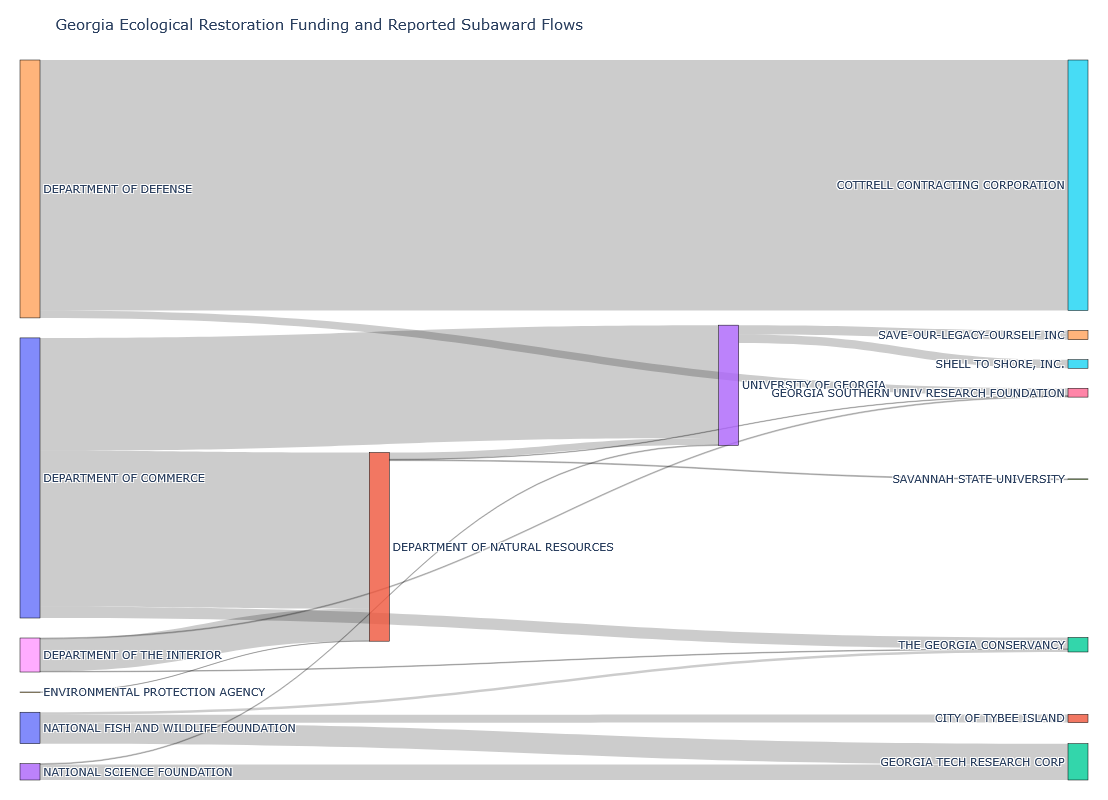

Number of Sankey nodes: 16
Number of Sankey links: 19
Total positive flow represented: $30,076,067.66

Assistance award reconciliation:
       transaction_sum   award_total    difference
count     2.400000e+01  2.400000e+01  2.400000e+01
mean      6.557784e+05  8.857627e+05 -2.299843e+05
std       1.237213e+06  1.367891e+06  6.549482e+05
min      -4.002440e+03  0.000000e+00 -2.775000e+06
25%       3.522600e+04  2.261655e+05 -8.750000e+03
50%       2.799836e+05  3.541555e+05  0.000000e+00
75%       5.772242e+05  7.306645e+05  0.000000e+00
max       5.687000e+06  5.687000e+06  1.131336e+04

Contract award reconciliation:
       transaction_sum  award_total  difference
count              1.0          1.0         1.0
mean               0.0   11663054.3 -11663054.3
std                NaN          NaN         NaN
min                0.0   11663054.3 -11663054.3
25%                0.0   11663054.3 -11663054.3
50%                0.0   11663054.3 -11663054.3
75%                0.0   11663054.3 -

In [15]:
# ##Chatgpt's suggested changes:
# import pandas as pd
# import plotly.graph_objects as go

# # =========================================================
# # 1. Helper Functions & Normalization Mappings
# # =========================================================

# def clean_id(x):
#     if pd.isna(x):
#         return None
#     return str(x).strip().upper()


# # ---------------------------------------------------------
# # Federal agency -> parent department mapping
# # ---------------------------------------------------------

# AGENCY_PARENT_MAP = {
#     'US ARMY CORPS OF ENGINEERS': 'DEPARTMENT OF DEFENSE',
#     'DEPARTMENT OF THE ARMY': 'DEPARTMENT OF DEFENSE',
#     'CIVIL WORKS': 'DEPARTMENT OF DEFENSE',
#     'CORPS OF ENGINEERS - CIVIL WORKS': 'DEPARTMENT OF DEFENSE',

#     'NATIONAL OCEANIC AND ATMOSPHERIC ADMINISTRATION':
#         'DEPARTMENT OF COMMERCE',

#     'UNITED STATES FISH AND WILDLIFE SERVICE':
#         'DEPARTMENT OF THE INTERIOR',
#     'NATIONAL PARK SERVICE':
#         'DEPARTMENT OF THE INTERIOR',

#     'US FOREST SERVICE':
#         'DEPARTMENT OF AGRICULTURE',
#     'NATURAL RESOURCES CONSERVATION SERVICE':
#         'DEPARTMENT OF AGRICULTURE',
# }


# def standardize_agency(agency_name):
#     if pd.isna(agency_name):
#         return 'UNKNOWN FEDERAL AGENCY'

#     name_upper = str(agency_name).strip().upper()

#     return AGENCY_PARENT_MAP.get(
#         name_upper,
#         name_upper
#     )


# # ---------------------------------------------------------
# # Recipient/entity name mapping
# # ---------------------------------------------------------

# ENTITY_CLEAN_MAP = {

#     # Georgia DNR
#     'NATURAL RESOURCES, GEORGIA DEPARTMENT OF':
#         'DEPARTMENT OF NATURAL RESOURCES',

#     'GEORGIA DEPARTMENT OF NATURAL RESOURCES':
#         'DEPARTMENT OF NATURAL RESOURCES',

#     'GA DEPT OF NATURAL RESOURCES':
#         'DEPARTMENT OF NATURAL RESOURCES',


#     # Georgia Southern
#     'GEORGIA SOUTHERN UNIVERSITY RESEARCH & SERVICE FOUNDATION INC':
#         'GEORGIA SOUTHERN UNIV RESEARCH FOUNDATION',

#     'GEORGIA SOUTHERN UNIVERSITY RESEARCH AND SERVICE FOUNDATION, INC.':
#         'GEORGIA SOUTHERN UNIV RESEARCH FOUNDATION',

#     'GEORGIA SOUTHERN UNIVERSITY RESEARCH AND SERVICE FOUNDATION':
#         'GEORGIA SOUTHERN UNIV RESEARCH FOUNDATION',

#     'GEORGIA SOUTHERN UNIVERSITY RESEARCH AND SERV':
#         'GEORGIA SOUTHERN UNIV RESEARCH FOUNDATION',


#     # UGA
#     'UNIVERSITY OF GEORGIA':
#         'UNIVERSITY OF GEORGIA',

#     'UNIVERSITY OF GEORGIA RESEARCH FOUNDATION, INC.':
#         'UNIVERSITY OF GEORGIA',


#     # Georgia Tech
#     'GEORGIA TECH RESEARCH CORP':
#         'GEORGIA TECH RESEARCH CORP',

#     'GEORGIA TECH RESEARCH CORPORATION':
#         'GEORGIA TECH RESEARCH CORP',


#     # Other nonprofit
#     'GEORGIA CONSERVANCY INC, THE':
#         'THE GEORGIA CONSERVANCY',
# }


# def clean_entity(name):
#     if pd.isna(name):
#         return None

#     n = str(name).strip().upper()

#     return ENTITY_CLEAN_MAP.get(n, n)


# # =========================================================
# # 2. Clean IDs and Monetary Fields
# # =========================================================

# # IDs
# for df, cols in [
#     (dfx, ['award_id_fain', 'assistance_award_unique_key']),
#     (dfy, ['prime_award_fain', 'prime_award_unique_key']),
#     (dfz, ['award_id_fain', 'assistance_award_unique_key']),
#     (dfw, ['award_id_piid', 'contract_award_unique_key'])
# ]:

#     for col in cols:
#         if col in df.columns:
#             df[col] = df[col].map(clean_id)


# # Monetary fields
# for df, cols in [

#     (dfx, [
#         'federal_action_obligation',
#         'total_obligated_amount',
#         'total_outlayed_amount_for_overall_award'
#     ]),

#     (dfy, [
#         'subaward_amount'
#     ]),

#     (dfw, [
#         'federal_action_obligation',
#         'total_dollars_obligated'
#     ])

# ]:

#     for col in cols:
#         if col in df.columns:
#             df[col] = pd.to_numeric(
#                 df[col],
#                 errors='coerce'
#             ).fillna(0)


# # =========================================================
# # 3. Assistance Prime Awards (dfx)
# # =========================================================

# # Sum transaction-level obligations for each FAIN.
# #
# # This is the primary amount used in the Sankey.
# #
# # total_obligated_amount is retained only as a diagnostic
# # and is NOT silently substituted for the transaction sum.

# dfx_amounts = (
#     dfx
#     .groupby('award_id_fain', as_index=False)
#     .agg(
#         transaction_sum=(
#             'federal_action_obligation',
#             'sum'
#         ),

#         award_total=(
#             'total_obligated_amount',
#             'max'
#         ),

#         outlay_total=(
#             'total_outlayed_amount_for_overall_award',
#             'max'
#         )
#     )
# )


# # Diagnostic comparison between transaction-level
# # obligations and the reported award total.

# dfx_amounts['difference'] = (
#     dfx_amounts['transaction_sum']
#     - dfx_amounts['award_total']
# )


# # The actual amount used in the Sankey
# dfx_amounts['effective_amount'] = (
#     dfx_amounts['transaction_sum']
# )


# # ---------------------------------------------------------
# # Get one set of award metadata per FAIN
# # ---------------------------------------------------------

# prime_assistance = (
#     dfx
#     .groupby('award_id_fain')
#     .first()
#     .reset_index()
# )


# prime_assistance = prime_assistance.merge(
#     dfx_amounts[
#         [
#             'award_id_fain',
#             'effective_amount'
#         ]
#     ],
#     on='award_id_fain',
#     how='left'
# )


# # ---------------------------------------------------------
# # Build assistance edges
# # ---------------------------------------------------------

# prime_assistance_edges = pd.DataFrame({

#     'award_id':
#         prime_assistance['award_id_fain'],

#     'source':
#         prime_assistance[
#             'funding_agency_name'
#         ]
#         .fillna(
#             prime_assistance[
#                 'awarding_agency_name'
#             ]
#         )
#         .apply(standardize_agency),

#     'target':
#         prime_assistance[
#             'recipient_name'
#         ]
#         .apply(clean_entity),

#     'amount':
#         prime_assistance[
#             'effective_amount'
#         ]
# })


# # =========================================================
# # 4. Contract Prime Awards (dfw)
# # =========================================================

# dfw_amounts = (
#     dfw
#     .groupby('award_id_piid', as_index=False)
#     .agg(
#         transaction_sum=(
#             'federal_action_obligation',
#             'sum'
#         ),

#         award_total=(
#             'total_dollars_obligated',
#             'max'
#         )
#     )
# )


# # # Use transaction-level obligations as the primary amount.
# # dfw_amounts['effective_amount'] = (
# #     dfw_amounts['transaction_sum']
# # )
# dfw_amounts['effective_amount'] = dfw_amounts.apply(
#     lambda r: (
#         r['award_total']
#         if r['transaction_sum'] == 0 and r['award_total'] > 0
#         else r['transaction_sum']
#     ),
#     axis=1
# )

# # Diagnostic comparison
# dfw_amounts['difference'] = (
#     dfw_amounts['transaction_sum']
#     - dfw_amounts['award_total']
# )

# dfw_fallbacks = dfw_amounts[
#     (dfw_amounts['transaction_sum'] == 0) &
#     (dfw_amounts['award_total'] > 0)
# ].copy()

# print("Contract awards using award-total fallback:")
# print(dfw_fallbacks)
# # ---------------------------------------------------------
# # Get one set of award metadata per PIID
# # ---------------------------------------------------------

# prime_contracts = (
#     dfw
#     .groupby('award_id_piid')
#     .first()
#     .reset_index()
# )


# prime_contracts = prime_contracts.merge(
#     dfw_amounts[
#         [
#             'award_id_piid',
#             'effective_amount'
#         ]
#     ],
#     on='award_id_piid',
#     how='left'
# )


# # ---------------------------------------------------------
# # Build contract edges
# # ---------------------------------------------------------

# prime_contract_edges = pd.DataFrame({

#     # NOTE:
#     # This is a PIID, not a FAIN, so we use a generic
#     # award_id field.
#     'award_id':
#         prime_contracts['award_id_piid'],

#     'source':
#         prime_contracts[
#             'funding_agency_name'
#         ]
#         .fillna(
#             prime_contracts[
#                 'awarding_agency_name'
#             ]
#         )
#         .apply(standardize_agency),

#     'target':
#         prime_contracts[
#             'recipient_name'
#         ]
#         .apply(clean_entity),

#     'amount':
#         prime_contracts[
#             'effective_amount'
#         ]
# })


# # =========================================================
# # 5. Subaward Edges (dfy)
# # =========================================================

# sub_edges = pd.DataFrame({

#     # FAIN of the associated prime award
#     'award_id':
#         dfy['prime_award_fain'],

#     'source':
#         dfy[
#             'prime_awardee_name'
#         ]
#         .apply(clean_entity),

#     'target':
#         dfy[
#             'subawardee_name'
#         ]
#         .apply(clean_entity),

#     'amount':
#         dfy[
#             'subaward_amount'
#         ]
# })


# # =========================================================
# # 6. Combine All Funding Flows
# # =========================================================

# all_edges = pd.concat(
#     [
#         prime_assistance_edges,
#         prime_contract_edges,
#         sub_edges
#     ],
#     ignore_index=True
# )


# # ---------------------------------------------------------
# # Remove invalid records
# # ---------------------------------------------------------

# all_edges = all_edges[
#     all_edges['source'].notna()
#     & all_edges['target'].notna()
#     & all_edges['amount'].notna()
# ]


# # ---------------------------------------------------------
# # Keep only positive net flows
# #
# # Important:
# # We do this AFTER transaction-level obligations have
# # already been summed, so negative deobligations can
# # offset positive obligations rather than simply being
# # discarded individually.
# # ---------------------------------------------------------

# all_edges = all_edges[
#     all_edges['amount'] > 0
# ].copy()


# # =========================================================
# # 7. Aggregate Institutional Flows
# # =========================================================

# # Multiple awards between the same institutions are
# # combined into a single Sankey link.

# sankey_edges = (
#     all_edges
#     .groupby(
#         ['source', 'target'],
#         as_index=False
#     )
#     .agg(
#         amount=('amount', 'sum')
#     )
# )


# # =========================================================
# # 8. Build Sankey Nodes
# # =========================================================

# nodes = list(
#     pd.unique(
#         sankey_edges[
#             ['source', 'target']
#         ]
#         .values
#         .ravel()
#     )
# )


# node_index = {
#     name: i
#     for i, name in enumerate(nodes)
# }


# # =========================================================
# # 9. Build Plotly Sankey
# # =========================================================

# fig = go.Figure(
#     go.Sankey(

#         arrangement='snap',

#         node=dict(
#             pad=20,
#             thickness=20,
#             line=dict(
#                 color='black',
#                 width=0.5
#             ),
#             label=nodes
#         ),

#         link=dict(

#             source=sankey_edges[
#                 'source'
#             ].map(node_index),

#             target=sankey_edges[
#                 'target'
#             ].map(node_index),

#             value=sankey_edges[
#                 'amount'
#             ],

#             hovertemplate=(
#                 'From: %{source.label}'
#                 '<br>'
#                 'To: %{target.label}'
#                 '<br>'
#                 'Amount: $%{value:,.2f}'
#                 '<extra></extra>'
#             )
#         )
#     )
# )


# # =========================================================
# # 10. Layout
# # =========================================================

# fig.update_layout(

#     title_text=(
#         'Georgia Ecological Restoration '
#         'Funding and Reported Subaward Flows'
#     ),

#     font_size=11,

#     height=800,

#     margin=dict(
#         l=20,
#         r=20,
#         t=60,
#         b=20
#     )
# )


# fig.show()


# # =========================================================
# # 11. Optional Diagnostics
# # =========================================================

# print(
#     f"Number of Sankey nodes: {len(nodes)}"
# )

# print(
#     f"Number of Sankey links: {len(sankey_edges)}"
# )

# print(
#     f"Total positive flow represented: "
#     f"${sankey_edges['amount'].sum():,.2f}"
# )


# # ---------------------------------------------------------
# # Assistance-award reconciliation
# #
# # Useful for checking whether the transaction sums in dfx
# # agree with USAspending's reported award totals.
# # ---------------------------------------------------------

# print("\nAssistance award reconciliation:")
# print(
#     dfx_amounts[
#         [
#             'transaction_sum',
#             'award_total',
#             'difference'
#         ]
#     ].describe()
# )


# # ---------------------------------------------------------
# # Contract-award reconciliation
# # ---------------------------------------------------------

# print("\nContract award reconciliation:")
# print(
#     dfw_amounts[
#         [
#             'transaction_sum',
#             'award_total',
#             'difference'
#         ]
#     ].describe()
# )

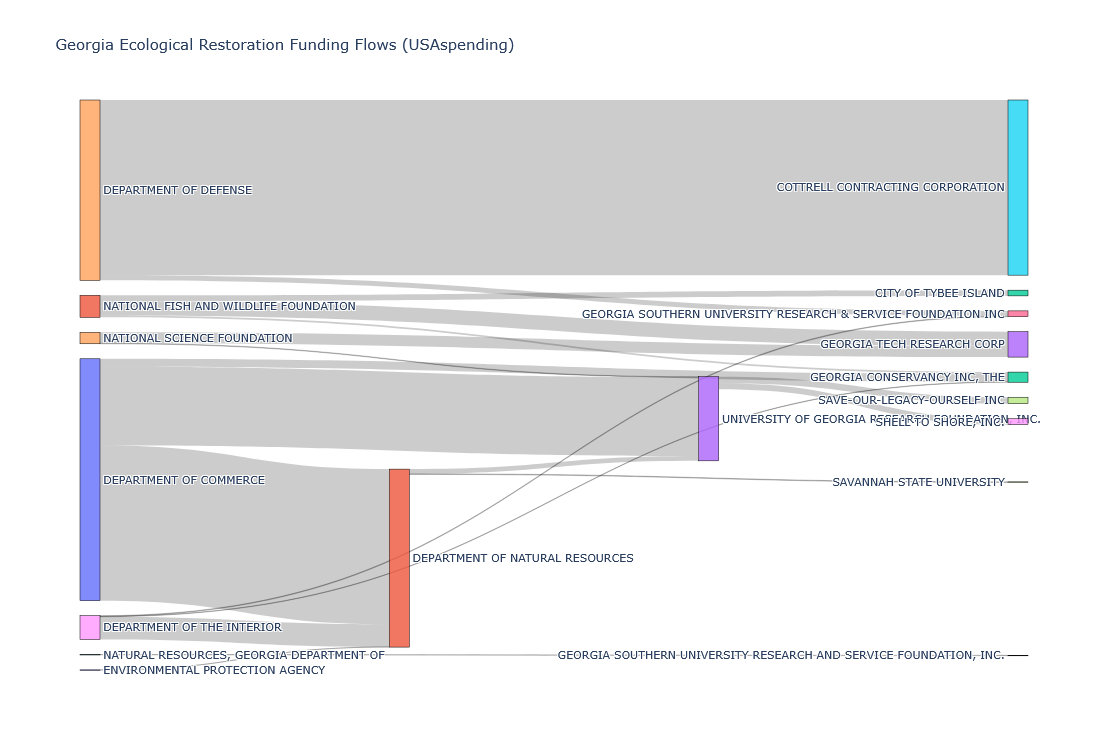

In [3]:
'''import pandas as pd
import plotly.graph_objects as go

# ---------------------------------------------------------
# 1. Helper Functions & Normalization Mappings
# ---------------------------------------------------------
def clean_id(x):
    if pd.isna(x):
        return None
    return str(x).strip().upper()

AGENCY_PARENT_MAP = {
    'US ARMY CORPS OF ENGINEERS': 'DEPARTMENT OF DEFENSE',
    'DEPARTMENT OF THE ARMY': 'DEPARTMENT OF DEFENSE',
    'CIVIL WORKS': 'DEPARTMENT OF DEFENSE',
    'CORPS OF ENGINEERS - CIVIL WORKS': 'DEPARTMENT OF DEFENSE',
    'NATIONAL OCEANIC AND ATMOSPHERIC ADMINISTRATION': 'DEPARTMENT OF COMMERCE',
    'UNITED STATES FISH AND WILDLIFE SERVICE': 'DEPARTMENT OF THE INTERIOR',
    'NATIONAL PARK SERVICE': 'DEPARTMENT OF THE INTERIOR',
    'US FOREST SERVICE': 'DEPARTMENT OF AGRICULTURE',
    'NATURAL RESOURCES CONSERVATION SERVICE': 'DEPARTMENT OF AGRICULTURE',
}

def standardize_agency(agency_name):
    if pd.isna(agency_name):
        return 'UNKNOWN FEDERAL AGENCY'
    name_upper = str(agency_name).strip().upper()
    return AGENCY_PARENT_MAP.get(name_upper, name_upper)

# Clean IDs across datasets
for df, cols in [
    (dfx, ['award_id_fain', 'assistance_award_unique_key']),
    (dfy, ['prime_award_fain', 'prime_award_unique_key']),
    (dfz, ['award_id_fain', 'assistance_award_unique_key']),
    (dfw, ['award_id_piid', 'contract_award_unique_key'])
]:
    for col in cols:
        if col in df.columns:
            df[col] = df[col].map(clean_id)

# ---------------------------------------------------------
# 2. Build Assistance Prime Edges (dfx) with Fallback Logic
# ---------------------------------------------------------
# Calculate transaction sum vs. award total fallback
dfx_amounts = dfx.groupby('award_id_fain').agg(
    transaction_sum=('federal_action_obligation', 'sum'),
    award_total=('total_obligated_amount', 'max')
).reset_index()

# If transaction sum is 0 but award_total > 0, fallback to award_total
dfx_amounts['effective_amount'] = dfx_amounts.apply(
    lambda r: r['award_total'] if (r['transaction_sum'] == 0 and r['award_total'] > 0) else r['transaction_sum'],
    axis=1
)

# Merge back metadata
prime_assistance = dfx.groupby('award_id_fain').first().reset_index()
prime_assistance = prime_assistance.merge(dfx_amounts[['award_id_fain', 'effective_amount']], on='award_id_fain')

prime_assistance_edges = pd.DataFrame({
    'award_id_fain': prime_assistance['award_id_fain'],
    'source': prime_assistance['funding_agency_name'].fillna(prime_assistance['awarding_agency_name']).apply(standardize_agency),
    'target': prime_assistance['recipient_name'].str.strip().str.upper(),
    'amount': prime_assistance['effective_amount']
})

# ---------------------------------------------------------
# 3. Build Contract Prime Edges (dfw) with Fallback Logic
# ---------------------------------------------------------
dfw_amounts = dfw.groupby('award_id_piid').agg(
    transaction_sum=('federal_action_obligation', 'sum'),
    award_total=('total_dollars_obligated', 'max')
).reset_index()

dfw_amounts['effective_amount'] = dfw_amounts.apply(
    lambda r: r['award_total'] if (r['transaction_sum'] == 0 and r['award_total'] > 0) else r['transaction_sum'],
    axis=1
)

prime_contracts = dfw.groupby('award_id_piid').first().reset_index()
prime_contracts = prime_contracts.merge(dfw_amounts[['award_id_piid', 'effective_amount']], on='award_id_piid')

prime_contract_edges = pd.DataFrame({
    'award_id_fain': prime_contracts['award_id_piid'],
    'source': prime_contracts['funding_agency_name'].fillna(prime_contracts['awarding_agency_name']).apply(standardize_agency),
    'target': prime_contracts['recipient_name'].str.strip().str.upper(),
    'amount': prime_contracts['effective_amount']
})

# ---------------------------------------------------------
# 4. Build Subaward Edges (dfy)
# ---------------------------------------------------------
sub_edges = pd.DataFrame({
    'award_id_fain': dfy['prime_award_fain'],
    'source': dfy['prime_awardee_name'].str.strip().str.upper(),
    'target': dfy['subawardee_name'].str.strip().str.upper(),
    'amount': pd.to_numeric(dfy['subaward_amount'], errors='coerce').fillna(0)
})

# ---------------------------------------------------------
# 5. Combine All Edges & Aggregate
# ---------------------------------------------------------
all_edges = pd.concat([prime_assistance_edges, prime_contract_edges, sub_edges], ignore_index=True)

# # Filter out zero or negative obligations
# all_edges = all_edges[all_edges['amount'] > 0]

# Consolidate duplicate source -> target flows
sankey_edges = all_edges.groupby(['source', 'target'], as_index=False).agg(amount=('amount', 'sum'))

# ---------------------------------------------------------
# 6. Build Plotly Sankey Diagram
# ---------------------------------------------------------
nodes = list(pd.unique(sankey_edges[['source', 'target']].values.ravel()))
node_index = {name: i for i, name in enumerate(nodes)}

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=sankey_edges['source'].map(node_index),
        target=sankey_edges['target'].map(node_index),
        value=sankey_edges['amount'],
        hovertemplate='From: %{source.label}<br>To: %{target.label}<br>Amount: $%{value:,.2f}<extra></extra>'
    )
))

fig.update_layout(
    title_text="Georgia Ecological Restoration Funding Flows (USAspending)",
    font_size=11,
    height=750
)

fig.show()'''

In [4]:
all_edges

,award_id_fain,source,target,amount
0,00D50916,ENVIRONMENTAL PROTECTION AGENCY,DEPARTMENT OF NATURAL RESOURCES,9551.00
1,1234449,NATIONAL SCIENCE FOUNDATION,GEORGIA TECH RESEARCH CORP,723886.00
2,1851032,NATIONAL SCIENCE FOUNDATION,"UNIVERSITY OF GEORGIA RESEARCH FOUNDATION, INC.",36968.00
3,F19AP00032,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,275881.00
4,F22AF02343,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,239507.46
5,F23AF02597,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,284086.26
6,F24AF02169,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,318505.38
7,F25AC01806,DEPARTMENT OF THE INTERIOR,"GEORGIA CONSERVANCY INC, THE",30000.00
8,F25AF01510,DEPARTMENT OF THE INTERIOR,DEPARTMENT OF NATURAL RESOURCES,394048.00
9,NA20NOS4190175,DEPARTMENT OF COMMERCE,DEPARTMENT OF NATURAL RESOURCES,0.00


In [5]:
# def clean_id(x):
#     if pd.isna(x):
#         return None
#     return str(x).strip().upper()


# for df, cols in [
#     (dfx, ['award_id_fain', 'assistance_award_unique_key', 'award_id_uri']),
#     (dfy, ['prime_award_fain', 'prime_award_unique_key']),
#     (dfz, ['award_id_fain', 'assistance_award_unique_key']),
# ]:
#     for col in cols:
#         if col in df.columns:
#             df[col] = df[col].map(clean_id)

# dfx['award_key'] = dfx['award_id_fain']
# dfy['award_key'] = dfy['prime_award_fain']
# dfz['award_key'] = dfz['award_id_fain']


# dfx.groupby('award_key')['federal_action_obligation'].sum()

# dfz[['award_key', 'total_obligated_amount']]
# dfx[['award_key', 'total_obligated_amount']]

In [6]:
# subawards = dfy[[
#     'prime_award_fain',
#     'prime_awardee_name',
#     'subawardee_name',
#     'subaward_amount',
#     'subaward_action_date',
#     'subaward_sam_report_id'
# ]].copy()

# subawards = subawards.rename(columns={
#     'prime_award_fain': 'award_key',
#     'prime_awardee_name': 'source',
#     'subawardee_name': 'target',
#     'subaward_amount': 'amount',
#     'subaward_action_date': 'date'
# })

# subawards

In [7]:
# import pandas as pd
# import plotly.graph_objects as go

# # Create the federal -> recipient edges
# prime_edges = dfx[[
#     'award_id_fain',
#     'recipient_name',
#     'federal_action_obligation',
#     'action_date',
#     'awarding_agency_name',
#     'funding_agency_name',
#     'cfda_title'
# ]].copy()

# # prime_edges['source'] = 'Federal Government'
# prime_edges['source'] = prime_edges['funding_agency_name']
# prime_edges['target'] = prime_edges['recipient_name']
# prime_edges['amount'] = prime_edges['federal_action_obligation']

# # Keep only the columns we need for the graph
# prime_edges = prime_edges[[
#     'award_id_fain',
#     'source',
#     'target',
#     'amount',
#     'action_date',
#     'awarding_agency_name',
#     'funding_agency_name',
#     'cfda_title'
# ]]

In [8]:
# prime_edges = (
#     prime_edges
#     .groupby(
#         ['award_id_fain', 'source', 'target'],
#         as_index=False
#     )
#     .agg(
#         amount=('amount', 'sum'),
#         first_action=('action_date', 'min'),
#         last_action=('action_date', 'max'),
#         awarding_agency=('awarding_agency_name', 'first'),
#         funding_agency=('funding_agency_name', 'first'),
#         award_name=('cfda_title', 'first')
#     )
# )

In [9]:
# sub_edges = dfy[[
#     'prime_award_fain',
#     'prime_awardee_name',
#     'subawardee_name',
#     'subaward_amount',
#     'subaward_action_date',
#     'subaward_description'
# ]].copy()

# sub_edges['source'] = sub_edges['prime_awardee_name']
# sub_edges['target'] = sub_edges['subawardee_name']
# sub_edges['amount'] = sub_edges['subaward_amount']

# sub_edges = sub_edges.rename(
#     columns={'prime_award_fain': 'award_id_fain'}
# )

# sub_edges = sub_edges[[
#     'award_id_fain',
#     'source',
#     'target',
#     'amount',
#     'subaward_action_date',
#     'subaward_description'
# ]]

In [30]:
# dfx['source'] = 'Federal Government'
# dfx['target'] = dfx['recipient_name']

In [46]:
# edges = pd.concat(
#     [prime_edges, sub_edges],
#     ignore_index=True
# )

# edges

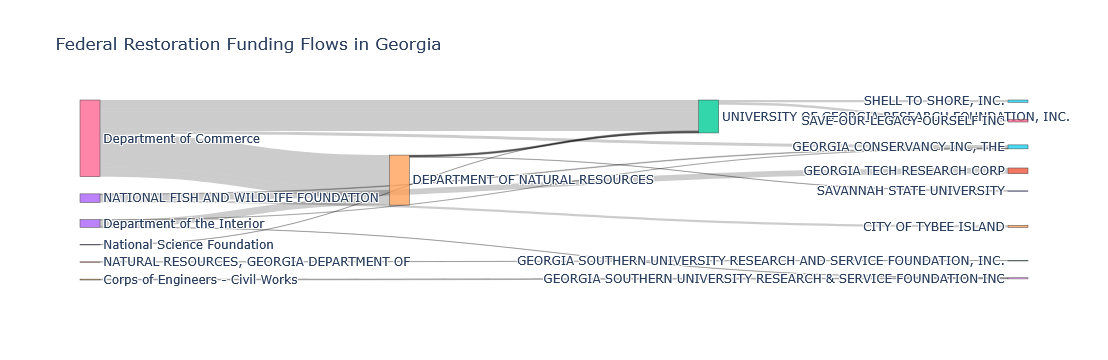

In [20]:
# import plotly.graph_objects as go

# nodes = pd.unique(
#     edges[['source', 'target']].values.ravel()
# )

# node_index = {name: i for i, name in enumerate(nodes)}

# fig = go.Figure(go.Sankey(
#     node=dict(
#         label=nodes
#     ),
#     link=dict(
#         source=edges['source'].map(node_index),
#         target=edges['target'].map(node_index),
#         value=edges['amount']
#     )
# ))

# fig.update_layout(
#     title="Federal Restoration Funding Flows in Georgia"
# )

# fig.show()

In [47]:
# prime_awards = (
#     dfx
#     .groupby("award_id_fain", as_index=False)
#     .agg(
#         federal_obligated=("federal_action_obligation", "sum"),
#         recipient=("recipient_name", "first"),
#         awarding_agency=("awarding_agency_name", "first"),
#         funding_agency=("funding_agency_name", "first"),
#         award_name=("cfda_title", "first"),
#         first_action=("action_date", "min"),
#         last_action=("action_date", "max")
#     )
# )

# subawards = dfy[[
#     "prime_award_fain",
#     "prime_awardee_name",
#     "subawardee_name",
#     "subaward_amount",
#     "subaward_action_date",
#     "subaward_description"
# ]].copy()

# subawards = subawards.rename(columns={
#     "prime_award_fain": "award_id_fain",
#     "prime_awardee_name": "source",
#     "subawardee_name": "target",
#     "subaward_amount": "amount"
# })


# subawards